# CycleGAN style transfer

Srinidhi, SID4 2342. This notebook defaults to **CPU smoke verification**. Its small synthetic outputs are not final lab results. Review the source and configuration before full training. Every run writes raw logs, provenance, metrics, outputs, and checkpoints to a new folder.

In [1]:
SID4 = 2342
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
print(dict(SID4=SID4, SEED=SEED, SLICE=SLICE, HP_ID=HP_ID, CLS_A=CLS_A, CLS_B=CLS_B))

{'SID4': 2342, 'SEED': 2342, 'SLICE': 342, 'HP_ID': 2, 'CLS_A': 2, 'CLS_B': 3}


In [2]:
from pathlib import Path
import os
import sys
roots = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in roots if (p / "src/lab1").is_dir() and (p / "pyproject.toml").is_file()), None)
if ROOT is None:
    raise RuntimeError("Extract the complete package and start this notebook inside its folder.")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
from lab1.common import environment, utc_now
from lab1.run import execute
print(environment())

{'captured_utc': '2026-09-18T22:31:28.614625+00:00', 'python': '3.12.14', 'platform': 'macOS-27.0-arm64-arm-64bit', 'machine': 'arm64', 'packages': {'torch': '2.11.0', 'torchvision': '0.26.0', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'scipy': '1.16.3', 'matplotlib': '3.11.2', 'datasets': '5.0.1', 'Pillow': '12.3.0', 'clean-fid': '0.1.35', 'lpips': '0.1.4', 'prdc': '0.2'}, 'cuda_available': False, 'cuda_build': None, 'cudnn': None, 'gpus': [], 'mps_available': True}


In [3]:
TASK = "cyclegan"
MODE = "smoke"  # "rehearsal" is short; "full" selects the complete training configuration.
DEVICE = "cpu"  # Change to "cuda" on RunPod or the college NVIDIA machine.
OVERRIDES = []  # See task README for actual image-data paths and optional overrides.
OUTPUT = Path("reproducibility/raw_logs/srinidhi") / ("notebook-" + MODE + "-" + utc_now().replace(":", "-")) / TASK
print({"task": TASK, "mode": MODE, "device": DEVICE, "output": str(OUTPUT)})

{'task': 'cyclegan', 'mode': 'smoke', 'device': 'cpu', 'output': 'reproducibility/raw_logs/srinidhi/notebook-smoke-2026-09-18T22-31-28.626070+00-00/cyclegan'}


In [4]:
result = execute(TASK, MODE, OUTPUT, DEVICE, overrides=OVERRIDES)
result["summary"]

{"event": "start", "task": "cyclegan", "mode": "smoke", "utc": "2026-09-18T22:31:28.639846+00:00", "device": "cpu"}


CycleGAN smoke: 1/2 updates, G=14.6402, 0.023s/update


CycleGAN smoke: 2/2 updates, G=14.4842, 0.011s/update


{"event": "completed", "task": "cyclegan", "mode": "smoke", "elapsed_seconds": 0.6022270829998888}


{'part': 3,
 'mode': 'smoke',
 'device': 'cpu',
 'seed': 2342,
 'data_kind': 'synthetic_pipeline_check',
 'class_results': False,
 'completed_updates': 2,
 'completed_epoch_fraction': 0.5,
 'steps_per_epoch': 4,
 'epoch_definition': 'one shuffled pass through larger training domain; smaller domain sampled independently with replacement',
 'parameter_counts': {'G_photo_to_monet': 32451,
  'G_monet_to_photo': 32451,
  'D_photo': 44537,
  'D_monet': 44537},
 'training_seconds': 0.03415320799831534,
 'session_wall_seconds': 0.07096795799589017,
 'training_source_images_per_second': 117.11930546018712,
 'throughput_definition': 'two source images per complete paired-domain G/D update; excludes data loading and evaluation',
 'peak_gpu_memory_bytes': None,
 'memory_note': 'CUDA peak allocated training memory; CPU/MPS metric unavailable',
 'nan_events': 0,
 'checkpoint': 'reproducibility/raw_logs/srinidhi/notebook-smoke-2026-09-18T22-31-28.626070+00-00/cyclegan/last.pt',
 'best_checkpoint': No

grids/step_0000001.png


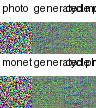

grids/step_0000002.png


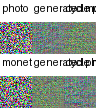

Artifacts:
RUN_LOG.txt
data_manifest.json
evaluation_step_0000002/metrics.json
evaluation_step_0000002/monet_to_photo/cycle/000000.png
evaluation_step_0000002/monet_to_photo/cycle/000001.png
evaluation_step_0000002/monet_to_photo/generated/000000.png
evaluation_step_0000002/monet_to_photo/generated/000001.png
evaluation_step_0000002/monet_to_photo/real_target/000000.png
evaluation_step_0000002/monet_to_photo/real_target/000001.png
evaluation_step_0000002/monet_to_photo/source/000000.png
evaluation_step_0000002/monet_to_photo/source/000001.png
evaluation_step_0000002/monet_to_photo/source_ids.json
evaluation_step_0000002/photo_to_monet/cycle/000000.png
evaluation_step_0000002/photo_to_monet/cycle/000001.png
evaluation_step_0000002/photo_to_monet/generated/000000.png
evaluation_step_0000002/photo_to_monet/generated/000001.png
evaluation_step_0000002/photo_to_monet/real_target/000000.png
evaluation_step_0000002/photo_to_monet/real_target/000001.png
evaluation_step_0000002/photo_to_monet/s

In [5]:
from IPython.display import display, Image
figures = sorted(p for p in OUTPUT.rglob("*.png") if p.is_file() and
                 (TASK != "cyclegan" or "grids" in p.relative_to(OUTPUT).parts))
for path in figures:
    print(path.relative_to(OUTPUT))
    display(Image(filename=str(path), width=700))
print("Artifacts:")
for path in sorted(OUTPUT.rglob("*")):
    if path.is_file() and path.suffix not in {".pt", ".pth"}:
        print(path.relative_to(OUTPUT))

## Interpretation to write after the real run

Explain the architecture and hyperparameters in your own words. Report the actual data split and hardware. Use generated evidence for metrics and failure analysis. Keep smoke, cloud rehearsal, and college full-run results separate. For the team report, compare all members on the agreed evaluation protocol.